In [1]:
import pandas as pd
import numpy as np
import joblib
import re
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

print('Libraries loaded.')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded.


## 1. Load & Explore Dataset

In [13]:
# Adjust path if your CSV lives elsewhere
CSV_PATH = 'datasets/email/emails.csv'

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nFirst 3 rows (first 6 cols + label):')
display(df[list(df.columns[:5]) + ['Prediction']].head(3))

Shape: (5172, 3002)

First 3 rows (first 6 cols + label):


,Email No.,the,to,ect,and,Prediction
0,Email 1,0,0,1,0,0
1,Email 2,8,13,24,6,0
2,Email 3,0,0,1,0,0


Label distribution:
  Legitimate (0): 3672
  Phishing   (1): 1500


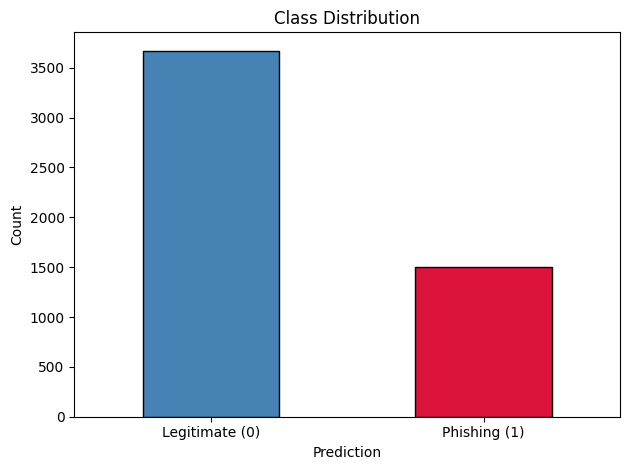

In [14]:
print('Label distribution:')
counts = df['Prediction'].value_counts()
print(f"  Legitimate (0): {counts[0]}")
print(f"  Phishing   (1): {counts[1]}")

counts.plot(kind='bar', color=['steelblue', 'crimson'], edgecolor='black')
plt.xticks([0, 1], ['Legitimate (0)', 'Phishing (1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Prepare Features & Labels

In [15]:
# Drop the row-identifier column; keep all 3 000 word-count columns + label
df = df.drop(columns=['Email No.'])

FEATURE_COLS = [c for c in df.columns if c != 'Prediction']
print(f'Number of features (vocabulary size): {len(FEATURE_COLS)}')

X = df[FEATURE_COLS].values
y = df['Prediction'].values

print(f'X shape: {X.shape}  |  y shape: {y.shape}')

Number of features (vocabulary size): 3000
X shape: (5172, 3000)  |  y shape: (5172,)


## 3. Train / Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')

Train: 4137 samples  |  Test: 1035 samples


## 4. Train Model Multinomial Naive Bayes

In [17]:
nb_model = MultinomialNB(alpha=1.0)   # alpha=1.0 → Laplace smoothing
nb_model.fit(X_train, y_train)

cv_scores = cross_val_score(nb_model, X, y, cv=5, scoring='accuracy')
print(f'5-fold CV Accuracy: {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})')

5-fold CV Accuracy: 0.9408  (±0.0199)


## 5. Evaluate on Hold-out Test Set

In [18]:
y_pred = nb_model.predict(X_test)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

Test Accuracy : 0.9420

              precision    recall  f1-score   support

  Legitimate       0.98      0.94      0.96       735
    Phishing       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



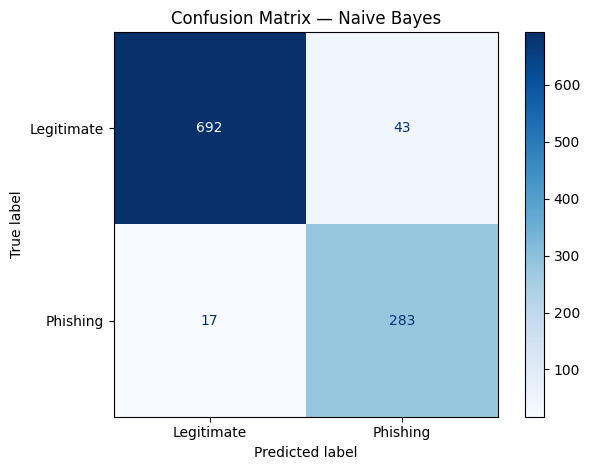

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.show()

### Top discriminative words

In [20]:
# Log-probability difference: large positive → strong phishing signal
log_prob_diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]
top_idx = np.argsort(log_prob_diff)[::-1][:20]
top_words = [(FEATURE_COLS[i], round(log_prob_diff[i], 3)) for i in top_idx]

print('Top 20 phishing-indicative words:')
for word, score in top_words:
    print(f'  {word:<20} {score}')

Top 20 phishing-indicative words:
  nbsp                 6.713
  pills                6.288
  computron            5.794
  viagra               5.767
  font                 5.742
  href                 5.539
  prescription         5.518
  arial                5.435
  drug                 5.435
  meds                 5.403
  border               5.386
  img                  5.3
  paliourg             5.225
  src                  5.186
  php                  5.155
  drugs                5.112
  valign               4.96
  darial               4.947
  voip                 4.921
  moopid               4.895


## 6. Save Model & Vocabulary

The **vocabulary** (ordered list of feature column names) is required by `app.py` to convert raw email text into the same feature vector at inference time.

In [21]:
joblib.dump(nb_model, 'email_model.pkl')
joblib.dump(FEATURE_COLS, 'email_vocabulary.pkl')

print('Saved: email_model.pkl')
print('Saved: email_vocabulary.pkl')
print(f'Vocabulary contains {len(FEATURE_COLS)} words.')

Saved: email_model.pkl
Saved: email_vocabulary.pkl
Vocabulary contains 3000 words.


## 7. Simulate API Inference

Replicates exactly what `app.py`'s `/predict_email` endpoint does when it receives raw email text.

In [22]:
def text_to_feature_vector(text: str, vocabulary: list) -> pd.DataFrame:
    """Convert raw email text into a BoW feature vector aligned to vocabulary."""
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    word_counts = Counter(tokens)
    features = {word: word_counts.get(word, 0) for word in vocabulary}
    return pd.DataFrame([features])[vocabulary]


# --- load saved artefacts (simulates what app.py does on startup) ---
loaded_model = joblib.load('email_model.pkl')
loaded_vocab = joblib.load('email_vocabulary.pkl')


def predict_email_text(text: str):
    vec = text_to_feature_vector(text, loaded_vocab)
    pred = loaded_model.predict(vec)[0]
    proba = loaded_model.predict_proba(vec)[0]
    is_phishing = bool(pred == 1)
    confidence = proba[1] if is_phishing else proba[0]
    return {
        'verdict'    : 'PHISHING' if is_phishing else 'LEGITIMATE',
        'is_phishing': is_phishing,
        'confidence' : round(float(confidence), 4),
        'risk_score' : int(proba[1] * 100),
    }


# Test 1 — obvious spam
spam_text = """
Congratulations! You have won a FREE prize. Click the link below to claim your money.
Visit http://free-prize-claim.com and enter your account details immediately.
Limited time offer — act now to get your cash reward online!
"""

# Test 2 — legitimate business email
ham_text = """
Hi team, please find attached the quarterly gas contract report for review.
The volumes are aligned with the March nominations. Let me know if you have questions.
Thanks, John
"""

print('--- SPAM SAMPLE ---')
print(predict_email_text(spam_text))

print('\n--- LEGITIMATE SAMPLE ---')
print(predict_email_text(ham_text))

--- SPAM SAMPLE ---
{'verdict': 'PHISHING', 'is_phishing': True, 'confidence': 1.0, 'risk_score': 99}

--- LEGITIMATE SAMPLE ---
{'verdict': 'LEGITIMATE', 'is_phishing': False, 'confidence': 1.0, 'risk_score': 0}


c:\Users\0adit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
c:\Users\0adit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
c:\Users\0adit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
c:\Users\0adit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
